<a href="https://colab.research.google.com/github/Umukundwa004/linear_regression_model/blob/main/bike_rental_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [62]:
import kagglehub

# Download latest version
path= kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/bike-sharing-dataset


In [63]:
import os

df = pd.read_csv(os.path.join(path, 'hour.csv'))
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [64]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


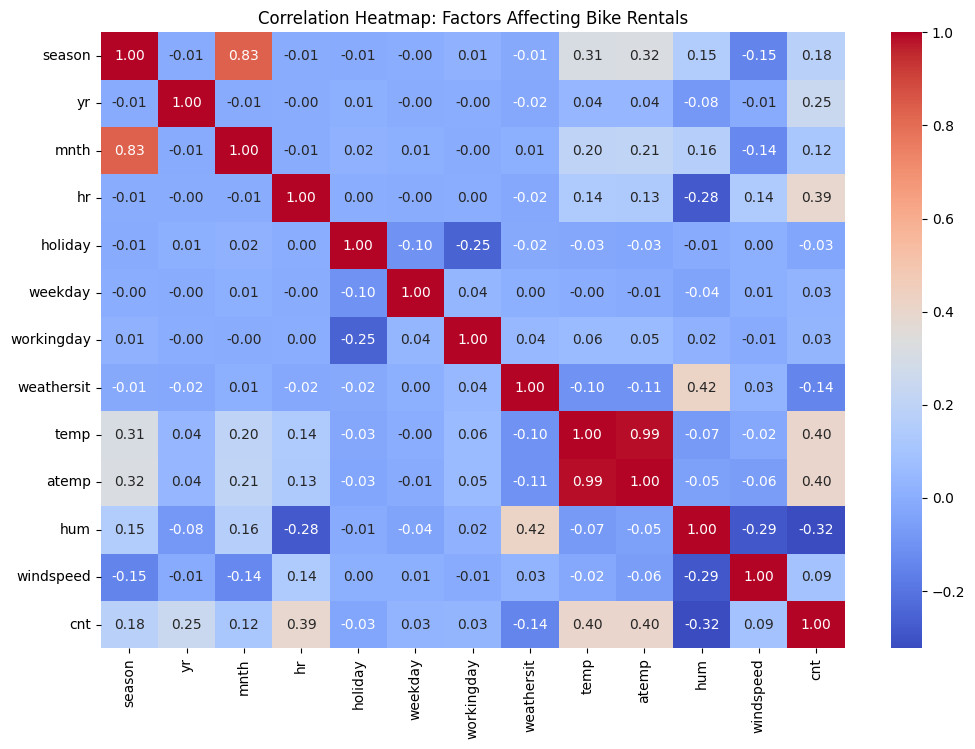

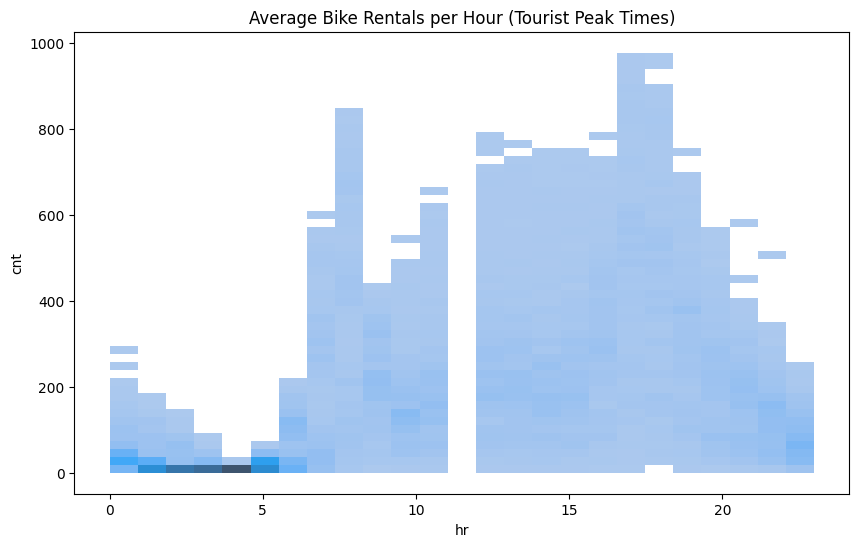

In [65]:
# Dropping 'instant' (ID) and 'dteday' (already have yr/mnth/hr columns)
# Also dropping 'casual' and 'registered' because they sum up to 'cnt' (target) and for creating new dataframe
df_clean = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)


# Visualization 1: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: Factors Affecting Bike Rentals")
plt.show()
# Interpretation: 'temp' and 'hr' show high positive correlation with 'cnt'.

# Visualization 2: Hourly distribution of rentals
plt.figure(figsize=(10, 6))
sns.histplot(x='hr', y='cnt', data=df)
plt.title("Average Bike Rentals per Hour (Tourist Peak Times)")
plt.show()

In [66]:
# Features (X)all columns axcept "cnt" and Target (y) "cnt"
X = df_clean.drop('cnt', axis=1)
y = df_clean['cnt']

# Identify categorical columns that are currently integers but should be one-hot encoded
categorical_cols = ['season', 'yr', 'mnth', 'hr', 'holiday','weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']

# Apply one-hot encoding to these categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True)

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

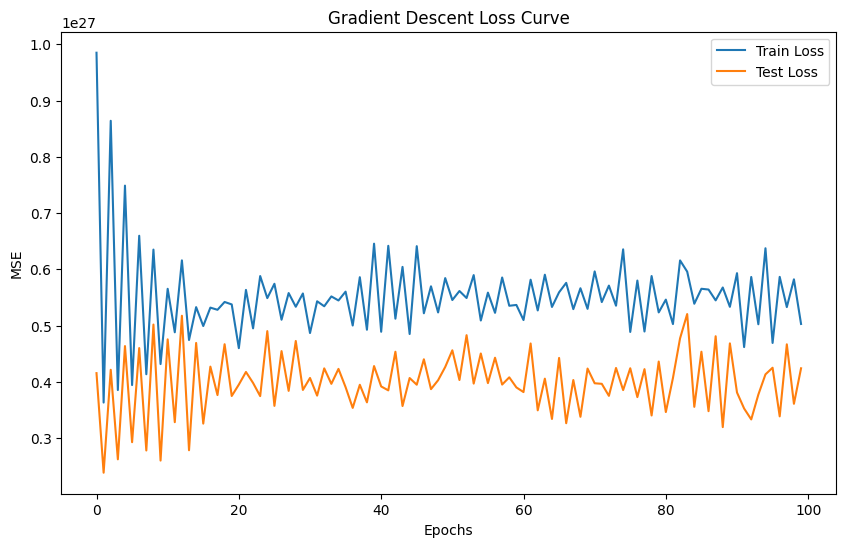

RandomForestRegressor()

In [67]:
# 1. Linear Regression with Gradient Descent
model_lr = SGDRegressor(max_iter=1, tol=1e-3, warm_start=True, learning_rate='constant', eta0=0.1)
train_losses = []
test_losses = [] # Initialize list to store test losses

# Manual loop to capture loss for the Loss Curve
for epoch in range(100):
    model_lr.partial_fit(X_train_scaled, y_train)

    # Calculate training loss
    y_pred_train = model_lr.predict(X_train_scaled)
    train_loss = mean_squared_error(y_train, y_pred_train)
    train_losses.append(train_loss)

    # Calculate test loss
    y_pred_test = model_lr.predict(X_test_scaled)
    test_loss = mean_squared_error(y_test, y_pred_test)
    test_losses.append(test_loss)

# Plot Loss Curve for both train and test data
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Gradient Descent Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

# 2. Decision Tree
model_decision_tree = DecisionTreeRegressor()
model_decision_tree.fit(X_train_scaled, y_train)

# 3. Random Forest
model_random_forest = RandomForestRegressor(n_estimators=100)
model_random_forest.fit(X_train_scaled, y_train)

Linear MSE: 424097087250841715620184064.00
Linear MAE: 10215043582198.84
Linear RMSE: 20593617633889.43
Linear R2: -13162641218465463009280.00
---------------------------------
Decision_Tree MSE: 5177.36
Decision_Tree MAE: 42.44
Decision_Tree RMSE: 71.95
Decision_Tree R2: 0.84
---------------------------------
Random_Forest MSE: 2650.84
Random_Forest MAE: 32.01
Random_Forest RMSE: 51.49
Random_Forest R2: 0.92
---------------------------------


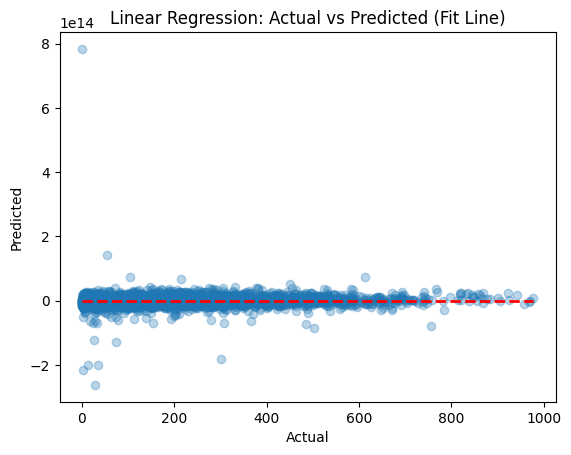

Saved Random_Forest as the best model.


In [68]:
# Evaluating models for evaluating th perfomance of trained model
from sklearn.metrics import mean_absolute_error, r2_score

models = {'Linear': model_lr, 'Decision_Tree': model_decision_tree, 'Random_Forest': model_random_forest}
results = {}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results[name] = mse
    print(f"{name} MSE: {mse:.2f}")
    print(f"{name} MAE: {mae:.2f}")
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} R2: {r2:.2f}")
    print("---------------------------------")

# Scatter Plot for Linear Regression (Actual vs Predicted)
plt.scatter(y_test, model_lr.predict(X_test_scaled), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Linear Regression: Actual vs Predicted (Fit Line)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Save the Best Model (Usually Random Forest for this dataset)
best_model_name = min(results, key=results.get)
joblib.dump(models[best_model_name], 'best_bike_model.pkl')
print(f"Saved {best_model_name} as the best model.")

In [69]:
# Load model and scaler
loaded_model = joblib.load('best_bike_model.pkl')

# Use the first row of X_test_scaled as our test point
single_point = X_test_scaled[0].reshape(1, -1)
prediction = loaded_model.predict(single_point)

print(f"Input features (Scaled): {single_point}")
print(f"Predicted Bike Rentals: {round(prediction[0])}")
print(f"Actual Bike Rentals: {y_test.iloc[0]}")

Input features (Scaled): [[ 0.31122666 -0.58324726 -0.5943246   1.76687577 -1.00381942 -0.28787584
  -0.30454133 -0.29986409 -0.30637085 -0.30256292 -0.30861278 -0.30524585
  -0.30071809 -0.29972159  3.3588394  -0.30889227 -0.21200356 -0.20695237
  -0.2046741  -0.20524565 -0.20827172 -0.20789548 -0.20827172 -0.20995787
  -0.20977108 -0.20562595 -0.20977108 -0.20958415 -0.20920987 -0.20958415
  -0.20902252  4.77135326 -0.21051742 -0.20920987 -0.2086474  -0.21033104
  -0.20429232 -0.20845963 -0.20883503 -0.17122538 -0.41086546  2.4758319
  -0.40583001 -0.40631073 -0.40907013 -0.40954921  0.68180749 -0.59798183
  -0.2984371  -0.01199477 -0.03174889 -0.03286441 -0.03059289 -0.05303811
  -0.06692866 -0.09052261 -0.11484989 -0.09524933 -0.14046383 -0.1539792
  -0.18035736 -0.17757497 -0.13309644 -0.19394522 -0.19173839 -0.19888278
  -0.19927328 -0.14875852 -0.19193991 -0.17993175 -0.17144779 -0.17950526
  -0.12767603 -0.17779035 -0.1820511  -0.18289283  5.33437049 -0.13448899
  -0.20486477 -